<a href="https://colab.research.google.com/github/guneetnagia/LearnML/blob/timeseries/timeseries_seasonality_docomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import plotly.express as px
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

In [3]:
data = pd.read_csv('AirPassengers.csv')

In [4]:
def plotting(title, data, x,y,x_label, y_label, lam=None):
  fig = px.line(data, x=data[x], y=data[y], labels = {x:x_label, y:y_label})

  fig.update_layout(template="simple_white", font=dict(size=18),
                    title_text=title, width=650,
                    title_x=0.5, height=400)
  fig.show()

In [5]:
plotting(title="Airline Passengers", data=data, x="Month", y="#Passengers", x_label="date", y_label="Passengers")

In [10]:
data["Passenger_season_diff"] = data['#Passengers'].diff(periods=12)

plotting(title="Airline Passengers", data=data,
         x="Month", y="Passenger_season_diff",
         x_label="Date", y_label="Passengers Seasonal Difference")

In [11]:
def adf_test(series):
  """using an ADF test to determine if a series is staionary"""
  test_results = adfuller(series)

  print('ADF statistic:', test_results[0])
  print("p-value:", test_results[1])
  print('Critical Values:')
  for thres, adf_stat in test_results[4].items():
    print("\t%s: %.2f" % (thres, adf_stat))

In [13]:
adf_test(data["Passenger_season_diff"][12:])

ADF statistic: -3.383020726492481
p-value: 0.011551493085514952
Critical Values:
	1%: -3.48
	5%: -2.88
	10%: -2.58


In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

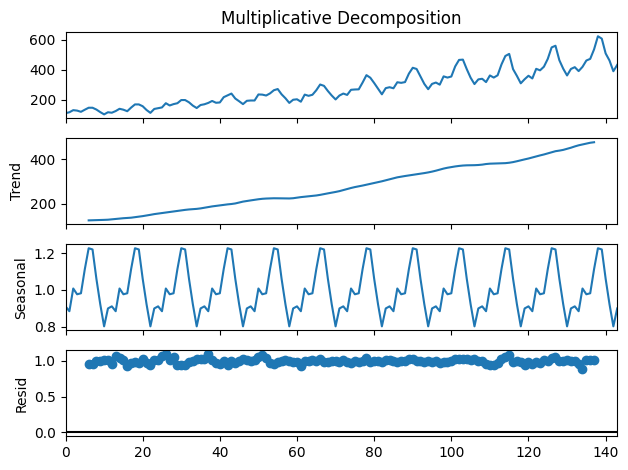

In [21]:
data.rename(columns={"#Passengers": "Multiplicative Decomposition"}, inplace=True)
decomposition_plot_multi = seasonal_decompose(data['Multiplicative Decomposition'],
                                              model="multiplicative",
                                              period=12)
decomposition_plot_multi.plot()
plt.show()

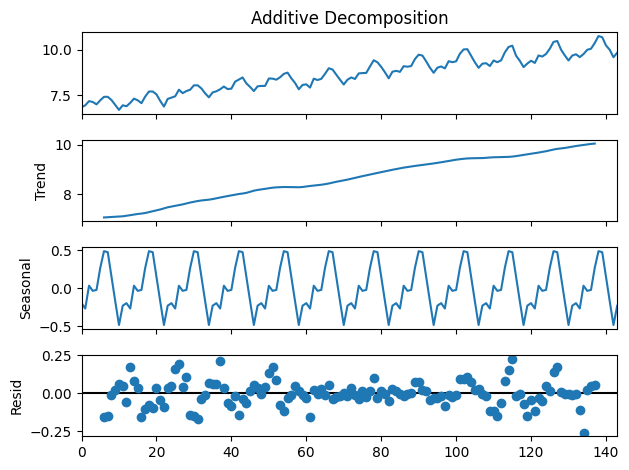

In [26]:
data['Additive Decomposition'], lam = boxcox(data['Multiplicative Decomposition'])
decomposition_plot_add = seasonal_decompose(data['Additive Decomposition'],
                                            model='additive',
                                            period=12)
decomposition_plot_add.plot()
plt.show()